In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from eqpolarity.utils import construct_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load your data
X = np.load('your_data.npy')       # shape: (N, 600, 1)
y = np.load('your_labels.npy')     # shape: (N,)

# Split into train (40%) and test (60%)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.4, stratify=y, random_state=42)

# Build model and load pretrained weights
input_shape = (600, 1)
model = construct_model(input_shape)
model.load_weights('models/best_weigths_Binary_SCSN_Best.h5')

# Evaluate BEFORE fine-tuning
y_pred_before = (model.predict(X_test, batch_size=128) >= 0.5).astype(int)
acc_before = accuracy_score(y_test, y_pred_before)
print(f"Before fine-tuning accuracy: {acc_before:.2%}")


4/4 [==============================] - 6s 1s/step
Before fine-tuning accuracy: 94.17%


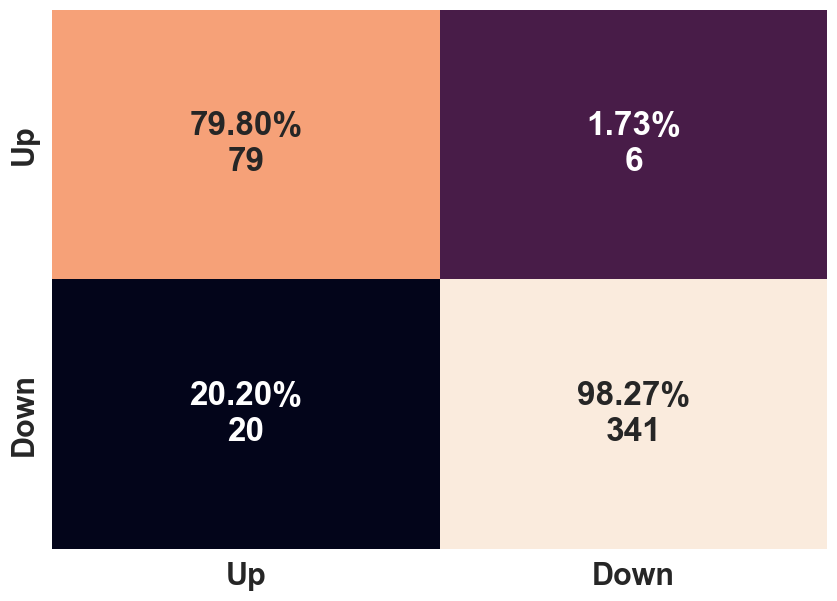

In [5]:
from eqpolarity import plot_confusionmatrix
from sklearn.metrics import confusion_matrix
cf_before = confusion_matrix(y_test, y_pred_before)

plot_confusionmatrix(
    cf=cf_before,
    categories=['Up', 'Down'],
    figname='conf_matrix_before_transferlearning.png',
    ifshow=True  # Set to False if you just want to save it
)


In [6]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), 
              loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_path = 'fine_tuned_model.weights.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, save_weights_only=True, mode='max', verbose=1)
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Fit
model.fit(X_train, y_train, 
          validation_split=0.1,
          epochs=50, 
          batch_size=128, 
          callbacks=[checkpoint, lr_reduce],
          verbose=1)


Epoch 1/50
3/3 [==============================] - ETA: 0s - loss: 0.7336 - accuracy: 0.9135
Epoch 1: val_accuracy improved from -inf to 0.96667, saving model to fine_tuned_model.weights.h5
3/3 [==============================] - 20s 4s/step - loss: 0.7336 - accuracy: 0.9135 - val_loss: 0.9216 - val_accuracy: 0.9667 - lr: 0.0010
Epoch 2/50
3/3 [==============================] - ETA: 0s - loss: 0.4131 - accuracy: 0.9436
Epoch 2: val_accuracy did not improve from 0.96667
3/3 [==============================] - 11s 3s/step - loss: 0.4131 - accuracy: 0.9436 - val_loss: 1.0118 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 3/50
3/3 [==============================] - ETA: 0s - loss: 0.3906 - accuracy: 0.9474
Epoch 3: val_accuracy did not improve from 0.96667
3/3 [==============================] - 11s 3s/step - loss: 0.3906 - accuracy: 0.9474 - val_loss: 1.0241 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 4/50
3/3 [==============================] - ETA: 0s - loss: 0.3482 - accuracy: 0.9511
Epoch 4: val_

In [7]:
# Load best weights from fine-tuning
model.load_weights(checkpoint_path)

# Predict again
y_pred_after = (model.predict(X_test, batch_size=128) >= 0.5).astype(int)

# Evaluate
acc_after = accuracy_score(y_test, y_pred_after)
print(f"After fine-tuning accuracy: {acc_after:.2%}")

print("Precision:", precision_score(y_test, y_pred_after))
print("Recall:", recall_score(y_test, y_pred_after))
print("F1:", f1_score(y_test, y_pred_after))


4/4 [==============================] - 6s 1s/step
After fine-tuning accuracy: 95.74%
Precision: 0.9776536312849162
Recall: 0.9695290858725761
F1: 0.9735744089012518


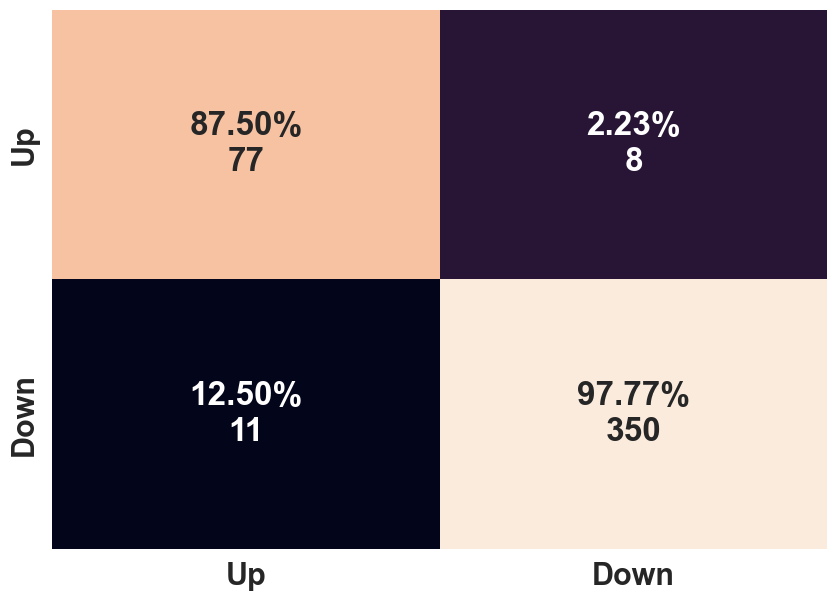

In [8]:
cf_after = confusion_matrix(y_test, y_pred_after)

plot_confusionmatrix(
    cf=cf_after,
    categories=['Up', 'Down'],
    figname='conf_matrix_after_transferlearning.png',
    ifshow=True
)
